# Análise do Pipeline KEV

Notebook de leitura e validação dos artefatos gerados pelo pacote `kev_pipeline`.

Uso recomendado:

- deixe `EXECUTE_PIPELINE=False` para modo offline
- use `EXECUTE_PIPELINE=True` apenas quando quiser rodar o pipeline a partir do notebook
- valide métricas, deltas e enriquecimentos nas células seguintes


In [1]:
# 1) configuração do notebook e do pipeline
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

ROOT = Path.cwd()
SRC = ROOT / "src"
MPL_CACHE_DIR = ROOT / ".cache_mpl"
MPL_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from kev_pipeline import PipelineConfig, run_pipeline
from kev_pipeline.env import load_dotenv

load_dotenv()

EXECUTE_PIPELINE = False
PIPELINE_MODE = "kev"
RUN_NVD = False
RUN_EPSS = False
RUN_GITHUB_ADVISORIES = False
SNAPSHOT_DATE = None  # ex.: "2026-03-29"
GENERATE_PLOTS = True
NVD_API_KEY = os.getenv("NVD_API_KEY", "")
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN", "")

OUT_DIR = ROOT / "artifacts" / "current"
SNAPSHOTS_DIR = ROOT / "artifacts" / "snapshots"
DELTAS_DIR = ROOT / "artifacts" / "deltas"

print(f"Root: {ROOT}")
print(f"Src: {SRC}")
print(f"Executar pipeline: {EXECUTE_PIPELINE}")
print(f"Pipeline mode: {PIPELINE_MODE}")
print(f"NVD ativo: {RUN_NVD}")
print(f"EPSS ativo: {RUN_EPSS}")
print(f"GitHub Advisories ativo: {RUN_GITHUB_ADVISORIES}")


Root: /Users/gabe/graphos
Src: /Users/gabe/graphos/src
Executar pipeline: False
Pipeline mode: kev
NVD ativo: False
EPSS ativo: False
GitHub Advisories ativo: False


/Users/gabe/graphos/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# 2) helpers de leitura dos artefatos gerados pelo pacote

def load_csv_if_exists(path):
    if not path:
        return pd.DataFrame()

    path = Path(path)
    if not path.exists() or not path.is_file():
        return pd.DataFrame()

    return pd.read_csv(path)


def load_json_if_exists(path):
    if not path:
        return {}

    path = Path(path)
    if not path.exists() or not path.is_file():
        return {}

    return json.loads(path.read_text(encoding="utf-8"))


def first_existing_path(*paths):
    for path in paths:
        if not path:
            continue
        candidate = Path(path)
        if candidate.exists() and candidate.is_file():
            return candidate
    return None


def build_config():
    snapshot_date = None
    if SNAPSHOT_DATE:
        snapshot_date = pd.to_datetime(SNAPSHOT_DATE).date()

    return PipelineConfig(
        pipeline_mode=PIPELINE_MODE,
        run_nvd=RUN_NVD,
        run_epss=RUN_EPSS,
        run_github_advisories=RUN_GITHUB_ADVISORIES,
        out_dir=OUT_DIR,
        snapshots_dir=SNAPSHOTS_DIR,
        deltas_dir=DELTAS_DIR,
        nvd_api_key=NVD_API_KEY,
        github_token=GITHUB_TOKEN,
        generate_plots=GENERATE_PLOTS,
        snapshot_date=snapshot_date or PipelineConfig().snapshot_date,
    )


In [3]:
# 3) execução principal via pacote kev_pipeline
if EXECUTE_PIPELINE:
    config = build_config()
    summary = run_pipeline(config)
    summary_path = Path(summary["files"]["summary"])
else:
    summary_path = OUT_DIR / "summary.json"
    summary = load_json_if_exists(summary_path)
    if not summary:
        snapshot_summaries = sorted((ROOT / "artifacts" / "snapshots").glob("*/summary.json"))
        if snapshot_summaries:
            summary_path = snapshot_summaries[-1]
            summary = load_json_if_exists(summary_path)
    if not summary:
        raise RuntimeError(
            "Nenhum summary.json encontrado em artifacts/current nem em artifacts/snapshots. "
            "Defina EXECUTE_PIPELINE=True para gerar os artefatos ou execute o pipeline antes."
        )

snapshot_dir = Path(summary["files"]["snapshot_dir"])
delta_dir = Path(summary["files"]["delta_dir"])

threats_daily_events_df = load_csv_if_exists(first_existing_path(summary["files"].get("threats_daily_events"), snapshot_dir / "threats_daily_events.csv"))
threats_daily_counts_df = load_csv_if_exists(first_existing_path(summary["files"].get("threats_daily_counts"), snapshot_dir / "threats_daily_counts.csv"))
threats_by_vendor_df = load_csv_if_exists(first_existing_path(summary["files"].get("threats_by_vendor"), snapshot_dir / "threats_by_vendor.csv"))
threats_by_product_df = load_csv_if_exists(first_existing_path(summary["files"].get("threats_by_product"), snapshot_dir / "threats_by_product.csv"))
enrich_nvd_df = load_csv_if_exists(first_existing_path(summary["files"].get("enrich_nvd"), snapshot_dir / "enrich_nvd.csv"))
enrich_epss_df = load_csv_if_exists(first_existing_path(summary["files"].get("enrich_epss"), snapshot_dir / "enrich_epss.csv"))
enrich_github_advisories_df = load_csv_if_exists(first_existing_path(summary["files"].get("enrich_github_advisories"), snapshot_dir / "enrich_github_advisories.csv"))
threats_daily_enriched_df = load_csv_if_exists(first_existing_path(summary["files"].get("threats_daily_enriched"), snapshot_dir / "threats_daily_enriched.csv"))
new_cves_today_df = load_csv_if_exists(delta_dir / "new_cves_today.csv")
new_urgent_today_df = load_csv_if_exists(delta_dir / "new_urgent_today.csv")
new_ransomware_today_df = load_csv_if_exists(delta_dir / "new_ransomware_today.csv")

print(json.dumps(summary, indent=2, ensure_ascii=False))


{
  "generated_at_utc": "2026-03-31T01:05:40.977404+00:00",
  "pipeline_mode": "kev",
  "run_nvd": false,
  "run_epss": false,
  "run_github_advisories": false,
  "snapshot_date": "2026-03-31",
  "rows": {
    "kev_raw": 1555,
    "threats_daily_events": 1555,
    "threats_daily_counts": 1609,
    "threats_by_vendor": 256,
    "threats_by_product": 626,
    "enrich_nvd": 0,
    "enrich_epss": 0,
    "enrich_github_advisories": 0,
    "threats_daily_enriched": 0
  },
  "metrics": {
    "unique_days": 398,
    "ransomware_flag_sum": 313,
    "urgent_sum": 1293,
    "min_days_to_due": 1,
    "min_date": "2021-11-03",
    "max_date": "2026-03-30"
  },
  "delta": {
    "previous_snapshot": "",
    "counts": {
      "new_cves_today": 1555,
      "new_urgent_today": 1293,
      "new_ransomware_today": 313
    },
    "files": {
      "new_cves_today": "/Users/gabe/graphos/artifacts/deltas/2026-03-31/new_cves_today.csv",
      "new_urgent_today": "/Users/gabe/graphos/artifacts/deltas/2026-03-31

## Análise e validação

Revise volume total, intervalo temporal, itens urgentes, `ransomware_flag`, agregações e delta em relação ao snapshot anterior.


In [4]:
# 4) análise e validação
if threats_daily_events_df.empty:
    raise RuntimeError("Execute a célula 3 (execução principal) antes desta análise.")

metrics = {
    "rows_threats_daily_events": int(len(threats_daily_events_df)),
    "rows_threats_daily_counts": int(len(threats_daily_counts_df)),
    "unique_days": int(threats_daily_events_df["date"].nunique()) if "date" in threats_daily_events_df.columns else 0,
    "ransomware_flag_sum": int(threats_daily_events_df["ransomware_flag"].sum()) if "ransomware_flag" in threats_daily_events_df.columns else 0,
    "urgent_sum": int(threats_daily_events_df["urgent"].sum()) if "urgent" in threats_daily_events_df.columns else 0,
    "min_date": "" if threats_daily_events_df.empty else str(threats_daily_events_df["date"].min()),
    "max_date": "" if threats_daily_events_df.empty else str(threats_daily_events_df["date"].max()),
    "delta_new_cves_today": int(len(new_cves_today_df)),
    "delta_new_urgent_today": int(len(new_urgent_today_df)),
    "delta_new_ransomware_today": int(len(new_ransomware_today_df)),
}

print("Métricas principais")
print(json.dumps(metrics, indent=2, ensure_ascii=False))

print()
print("Top vendors")
display(threats_by_vendor_df.head(15))

print()
print("Top products")
display(threats_by_product_df.head(15))

print()
print("Novos CVEs do delta")
display(new_cves_today_df.head(10))


Métricas principais
{
  "rows_threats_daily_events": 1555,
  "rows_threats_daily_counts": 1609,
  "unique_days": 398,
  "ransomware_flag_sum": 313,
  "urgent_sum": 1293,
  "min_date": "2021-11-03",
  "max_date": "2026-03-30",
  "delta_new_cves_today": 1555,
  "delta_new_urgent_today": 1293,
  "delta_new_ransomware_today": 313
}

Top vendors


,vendor,threat_count
0,Microsoft,362
1,Apple,93
2,Cisco,86
3,Adobe,76
4,Google,70
5,Oracle,42
6,Apache,38
7,Ivanti,32
8,VMware,26
9,D-Link,25



Top products


,product,threat_count
0,Windows,168
1,Multiple Products,79
2,Chromium V8,38
3,Internet Explorer,34
4,Flash Player,33
5,Office,28
6,Kernel,27
7,Win32k,25
8,Exchange Server,16
9,ColdFusion,15



Novos CVEs do delta


,date,cve_id,vendor,product,due_date,known_ransomware,ransomware_flag,days_to_due,notes,notes_link,notes_has_patch,notes_has_exploit,notes_critical_infra,notes_text,urgent
0,2021-11-03,CVE-2010-5326,SAP,NetWeaver,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2010-5326,NaN,False,False,False,NaN,False
1,2021-11-03,CVE-2012-0158,Microsoft,MSCOMCTL.OCX,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2012-0158,NaN,False,False,False,NaN,False
2,2021-11-03,CVE-2012-3152,Oracle,Fusion Middleware,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2012-3152,NaN,False,False,False,NaN,False
3,2021-11-03,CVE-2014-1812,Microsoft,Windows,2022-05-03,Known,1,181,https://nvd.nist.gov/vuln/detail/CVE-2014-1812,NaN,False,False,False,NaN,False
4,2021-11-03,CVE-2015-1641,Microsoft,Office,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2015-1641,NaN,False,False,False,NaN,False
5,2021-11-03,CVE-2015-4852,Oracle,WebLogic Server,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2015-4852,NaN,False,False,False,NaN,False
6,2021-11-03,CVE-2016-0167,Microsoft,Win32k,2022-05-03,Known,1,181,https://nvd.nist.gov/vuln/detail/CVE-2016-0167,NaN,False,False,False,NaN,False
7,2021-11-03,CVE-2016-0185,Microsoft,Windows,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2016-0185,NaN,False,False,False,NaN,False
8,2021-11-03,CVE-2016-3235,Microsoft,Office,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2016-3235,NaN,False,False,False,NaN,False
9,2021-11-03,CVE-2016-3643,SolarWinds,Virtualization Manager,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2016-3643,NaN,False,False,False,NaN,False


Matplotlib is building the font cache; this may take a moment.


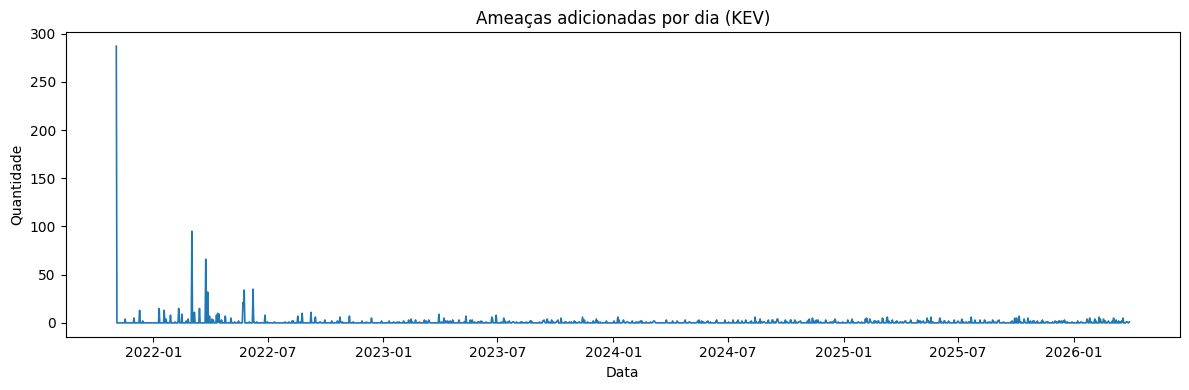

In [5]:
# 5) visualizações rápidas a partir dos CSVs gerados
if threats_daily_counts_df.empty:
    raise RuntimeError("Execute a célula 3 (execução principal) antes dos gráficos.")

import matplotlib.pyplot as plt
import plotly.express as px

fig_daily = px.line(
    threats_daily_counts_df,
    x="date",
    y="threat_count",
    title="Ameaças adicionadas por dia (KEV)",
)
display(HTML(fig_daily.to_html(include_plotlyjs="cdn", full_html=False)))

plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(threats_daily_counts_df["date"]), threats_daily_counts_df["threat_count"], linewidth=1.2)
plt.title("Ameaças adicionadas por dia (KEV)")
plt.xlabel("Data")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()


In [6]:
# 6) resumo final e localização dos artefatos
print("Resumo final")
print(json.dumps(summary, indent=2, ensure_ascii=False))

print()
print("Snapshot atual:")
print(snapshot_dir)

print()
print("Delta atual:")
print(delta_dir)


Resumo final
{
  "generated_at_utc": "2026-03-31T01:05:40.977404+00:00",
  "pipeline_mode": "kev",
  "run_nvd": false,
  "run_epss": false,
  "run_github_advisories": false,
  "snapshot_date": "2026-03-31",
  "rows": {
    "kev_raw": 1555,
    "threats_daily_events": 1555,
    "threats_daily_counts": 1609,
    "threats_by_vendor": 256,
    "threats_by_product": 626,
    "enrich_nvd": 0,
    "enrich_epss": 0,
    "enrich_github_advisories": 0,
    "threats_daily_enriched": 0
  },
  "metrics": {
    "unique_days": 398,
    "ransomware_flag_sum": 313,
    "urgent_sum": 1293,
    "min_days_to_due": 1,
    "min_date": "2021-11-03",
    "max_date": "2026-03-30"
  },
  "delta": {
    "previous_snapshot": "",
    "counts": {
      "new_cves_today": 1555,
      "new_urgent_today": 1293,
      "new_ransomware_today": 313
    },
    "files": {
      "new_cves_today": "/Users/gabe/graphos/artifacts/deltas/2026-03-31/new_cves_today.csv",
      "new_urgent_today": "/Users/gabe/graphos/artifacts/delt

## Enriquecimentos opcionais

NVD, EPSS e GitHub Advisories são opcionais. Falhas ou ausência de dados aparecem em `summary["enrichment_failures"]` e não invalidam a base principal do KEV.


In [7]:
# 7) validação da seção opcional de enriquecimento
print("Warnings:")
print(json.dumps(summary.get("warnings", []), indent=2, ensure_ascii=False))

print()
print("Falhas de enriquecimento:")
print(json.dumps(summary.get("enrichment_failures", {}), indent=2, ensure_ascii=False))

if not enrich_nvd_df.empty:
    print()
    print(f"NVD enrichment disponível: {len(enrich_nvd_df):,} linhas")
    display(enrich_nvd_df.head(10))
else:
    print()
    print("NVD sem dados nesta execução (ou desativado).")

if not enrich_epss_df.empty:
    print()
    print(f"EPSS enrichment disponível: {len(enrich_epss_df):,} linhas")
    display(enrich_epss_df.head(10))
else:
    print()
    print("EPSS sem dados nesta execução (ou desativado).")

if not enrich_github_advisories_df.empty:
    print()
    print(f"GitHub Advisories enrichment disponível: {len(enrich_github_advisories_df):,} linhas")
    display(enrich_github_advisories_df.head(10))
else:
    print()
    print("GitHub Advisories sem dados nesta execução (ou desativado).")

if not threats_daily_enriched_df.empty:
    print()
    print(f"Base enriquecida disponível: {len(threats_daily_enriched_df):,} linhas")
    display(threats_daily_enriched_df.head(10))
else:
    print()
    print("Base enriquecida não foi gerada nesta execução.")


Warnings:
[]

Falhas de enriquecimento:
{
  "count": 0,
  "items": []
}

NVD enrichment disponível: 1,555 linhas


,cve_id,nvd_published,nvd_last_modified,nvd_severity,nvd_cvss_score,nvd_description
0,CVE-2002-0367,2002-06-25T04:00:00.000,2025-10-22T01:15:30.693,HIGH,7.8,smss.exe debugging subsystem in Windows NT and...
1,CVE-2004-0210,2004-08-06T04:00:00.000,2025-10-22T01:15:31.677,HIGH,7.8,The POSIX component of Microsoft Windows NT an...
2,CVE-2004-1464,2004-12-31T05:00:00.000,2025-10-22T01:15:31.843,MEDIUM,5.9,Cisco IOS 12.2(15) and earlier allows remote a...
3,CVE-2005-2773,2005-09-02T23:03:00.000,2025-10-22T01:15:32.007,CRITICAL,9.8,HP OpenView Network Node Manager 6.2 through 7...
4,CVE-2006-1547,2006-03-30T22:02:00.000,2025-10-22T01:15:32.230,HIGH,7.5,ActionForm in Apache Software Foundation (ASF)...
5,CVE-2006-2492,2006-05-20T00:02:00.000,2025-10-22T01:15:32.400,HIGH,8.8,Buffer overflow in Microsoft Word in Office 20...
6,CVE-2007-0671,2007-02-03T01:28:00.000,2025-10-22T01:15:32.590,HIGH,8.8,Unspecified vulnerability in Microsoft Excel 2...
7,CVE-2007-3010,2007-09-18T21:17:00.000,2025-10-22T01:15:32.770,CRITICAL,9.8,masterCGI in the Unified Maintenance Tool in A...
8,CVE-2007-5659,2008-02-12T19:00:00.000,2025-10-22T01:15:32.927,HIGH,7.8,Multiple buffer overflows in Adobe Reader and ...
9,CVE-2008-0015,2009-07-07T23:30:00.187,2026-02-18T02:00:02.153,HIGH,8.8,Stack-based buffer overflow in the CComVariant...



EPSS enrichment disponível: 1,555 linhas


,cve_id,epss,epss_percentile,epss_date
0,CVE-2013-3163,0.82854,0.99237,2026-03-30
1,CVE-2013-2729,0.89132,0.99525,2026-03-30
2,CVE-2013-2597,0.06744,0.91233,2026-03-30
3,CVE-2013-2596,0.02696,0.85788,2026-03-30
4,CVE-2013-2551,0.91271,0.99648,2026-03-30
5,CVE-2013-2465,0.93220,0.99798,2026-03-30
6,CVE-2013-2423,0.93397,0.99813,2026-03-30
7,CVE-2013-2251,0.94328,0.99952,2026-03-30
8,CVE-2013-2094,0.65851,0.98494,2026-03-30
9,CVE-2013-1690,0.47055,0.97656,2026-03-30



GitHub Advisories sem dados nesta execução (ou desativado).

Base enriquecida disponível: 1,555 linhas


,date,cve_id,vendor,product,due_date,known_ransomware,ransomware_flag,days_to_due,notes,notes_link,...,notes_text,urgent,nvd_published,nvd_last_modified,nvd_severity,nvd_cvss_score,nvd_description,epss,epss_percentile,epss_date
0,2021-11-03,CVE-2010-5326,SAP,NetWeaver,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2010-5326,NaN,...,NaN,False,2016-05-13T10:59:00.173,2025-10-22T00:15:38.523,CRITICAL,10.0,The Invoker Servlet on SAP NetWeaver Applicati...,0.16904,0.94928,2026-03-30
1,2021-11-03,CVE-2012-0158,Microsoft,MSCOMCTL.OCX,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2012-0158,NaN,...,NaN,False,2012-04-10T21:55:01.687,2025-10-22T01:15:42.090,HIGH,8.8,"The (1) ListView, (2) ListView2, (3) TreeView,...",0.94319,0.99950,2026-03-30
2,2021-11-03,CVE-2012-3152,Oracle,Fusion Middleware,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2012-3152,NaN,...,NaN,False,2012-10-16T23:55:03.823,2025-10-22T01:15:44.837,CRITICAL,9.1,Unspecified vulnerability in the Oracle Report...,0.93535,0.99828,2026-03-30
3,2021-11-03,CVE-2014-1812,Microsoft,Windows,2022-05-03,Known,1,181,https://nvd.nist.gov/vuln/detail/CVE-2014-1812,NaN,...,NaN,False,2014-05-14T11:13:06.630,2025-10-22T01:15:55.620,HIGH,8.8,The Group Policy implementation in Microsoft W...,0.81626,0.99176,2026-03-30
4,2021-11-03,CVE-2015-1641,Microsoft,Office,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2015-1641,NaN,...,NaN,False,2015-04-14T20:59:05.250,2025-10-22T00:15:40.290,HIGH,7.8,"Microsoft Word 2007 SP3, Office 2010 SP2, Word...",0.93624,0.99838,2026-03-30
5,2021-11-03,CVE-2015-4852,Oracle,WebLogic Server,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2015-4852,NaN,...,NaN,False,2015-11-18T15:59:00.133,2025-10-22T00:15:43.800,CRITICAL,9.8,The WLS Security component in Oracle WebLogic ...,0.92870,0.99767,2026-03-30
6,2021-11-03,CVE-2016-0167,Microsoft,Win32k,2022-05-03,Known,1,181,https://nvd.nist.gov/vuln/detail/CVE-2016-0167,NaN,...,NaN,False,2016-04-12T23:59:30.430,2025-10-22T00:15:47.390,HIGH,7.8,The kernel-mode driver in Microsoft Windows Vi...,0.06082,0.90711,2026-03-30
7,2021-11-03,CVE-2016-0185,Microsoft,Windows,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2016-0185,NaN,...,NaN,False,2016-05-11T01:59:26.097,2025-10-22T00:15:47.547,HIGH,7.8,"Media Center in Microsoft Windows Vista SP2, W...",0.82752,0.99231,2026-03-30
8,2021-11-03,CVE-2016-3235,Microsoft,Office,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2016-3235,NaN,...,NaN,False,2016-06-16T01:59:36.983,2025-10-22T00:15:50.463,HIGH,7.8,"Microsoft Visio 2007 SP3, Visio 2010 SP2, Visi...",0.81164,0.99154,2026-03-30
9,2021-11-03,CVE-2016-3643,SolarWinds,Virtualization Manager,2022-05-03,Unknown,0,181,https://nvd.nist.gov/vuln/detail/CVE-2016-3643,NaN,...,NaN,False,2016-06-17T15:59:02.257,2025-10-22T00:15:51.510,HIGH,7.8,SolarWinds Virtualization Manager 6.3.1 and ea...,0.05418,0.90098,2026-03-30
